/opt/local/Library/Frameworks/Python.framework/Versions/2.7/lib/python2.7/site-packages/matplotlib/collections.py:571: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if self._edgecolors == str('face'):


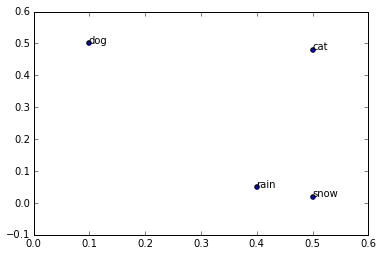

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt


vectors = {'dog' : [.1,.5], 'cat': [.5,.48], 'snow' : [.5,.02], 'rain' : [.4, .05] }

for word, item in vectors.iteritems():
    plt.annotate(word, xy=item)
    plt.scatter(item[0],item[1])

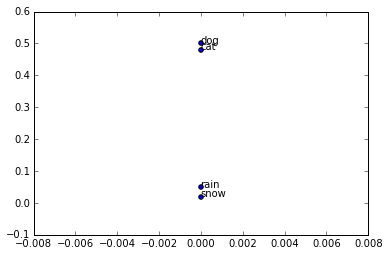

In [2]:
# Here we apply v, which zeros out the first dimension
for word, item in vectors.iteritems():
    plt.annotate(word, xy=(0,item[1]))
    plt.scatter(0,item[1])

In [3]:
import numpy as np
import pandas as pd
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences

Using TensorFlow backend.


In [ ]:
train=pd.read_csv('train.csv')
train=train.sample(frac=1)
list_classes = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
y = train[list_classes].values

In [5]:
train=pd.read_csv('train.csv')
train=train.sample(frac=1)
list_classes = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
y = train[list_classes].values

In [6]:
# Example of a data point
train.iloc[159552]

id                                                015f3e2d23d154b0
comment_text     OTRS ticket 2009051010000428 \n\nI draw your a...
toxic                                                            0
severe_toxic                                                     0
obscene                                                          0
threat                                                           0
insult                                                           0
identity_hate                                                    0
Name: 143706, dtype: object

In [7]:
max_features = 20000
maxlen = 200

list_sentences = train['comment_text'].values

# Tokenize
tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(list(list_sentences))
list_tokenized_train = tokenizer.texts_to_sequences(list_sentences)

# Pad
X_t = pad_sequences(list_tokenized_train, maxlen=maxlen)

In [8]:
X_t

array([[    0,     0,     0, ...,   670,  3252, 19464],
       [    0,     0,     0, ...,     3,    29,  1912],
       [    0,     0,     0, ...,     1,   535,    11],
       ...,
       [    0,     0,     0, ...,   753,     5,  9088],
       [    0,     0,     0, ...,   553,    20,   394],
       [    0,     0,     0, ...,    28,   394,  3039]], dtype=int32)

In [9]:
from keras.layers import Activation, Concatenate, Permute, SpatialDropout1D, RepeatVector, LSTM, Bidirectional, Multiply, Lambda, Dense, Dropout, Input,Flatten,Embedding
from keras.models import Model
import keras.backend as K

class Attention:
    def __call__(self, inp, combine=True, return_attention=True):
        # Expects inp to be of size (?, number of words, embedding dimension)
        
        repeat_size = int(inp.shape[-1])
        
        # Map through 1 Layer MLP
        x_a = Dense(repeat_size, kernel_initializer = 'glorot_uniform', activation="tanh", name="tanh_mlp")(inp) 
        
        # Dot with word-level vector
        x_a = Dense(1, kernel_initializer = 'glorot_uniform', activation='linear', name="word-level_context")(x_a)
        x_a = Flatten()(x_a) # x_a is of shape (?,200,1), we flatten it to be (?,200)
        att_out = Activation('softmax')(x_a) 
        
        # Clever trick to do elementwise multiplication of alpha_t with the correct h_t:
        # RepeatVector will blow it out to be (?,120, 200)
        # Then, Permute will swap it to (?,200,120) where each row (?,k,120) is a copy of a_t[k]
        # Then, Multiply performs elementwise multiplication to apply the same a_t to each
        # dimension of the respective word vector
        x_a2 = RepeatVector(repeat_size)(att_out)
        x_a2 = Permute([2,1])(x_a2)
        out = Multiply()([inp,x_a2])
        
        if combine:
        # Now we sum over the resulting word representations
            out = Lambda(lambda x : K.sum(x, axis=1), name='expectation_over_words')(out)
        
        if return_attention:
            out = (out, att_out)
                   
        return out

In [10]:
lstm_shape = 60
embed_size = 128

# Define the model
inp = Input(shape=(maxlen,))
emb = Embedding(input_dim=max_features, input_length = maxlen, output_dim=embed_size)(inp)
x = SpatialDropout1D(0.35)(emb)
x = Bidirectional(LSTM(lstm_shape, return_sequences=True, dropout=0.15, recurrent_dropout=0.15))(x)
x, attention = Attention()(x)
x = Dense(6, activation="sigmoid")(x)

model = Model(inputs=inp, outputs=x)
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

attention_model = Model(inputs=inp, outputs=attention) # Model to print out the attention data

In [11]:
model.summary()

__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            (None, 200)          0                                            
__________________________________________________________________________________________________
embedding_1 (Embedding)         (None, 200, 128)     2560000     input_1[0][0]                    
__________________________________________________________________________________________________
spatial_dropout1d_1 (SpatialDro (None, 200, 128)     0           embedding_1[0][0]                
__________________________________________________________________________________________________
bidirectional_1 (Bidirectional) (None, 200, 120)     90720       spatial_dropout1d_1[0][0]        
__________________________________________________________________________________________________
tanh_mlp (

In [ ]:
model.fit(X_t, y, validation_split=.2, epochs=3, verbose=1, batch_size=512)

Train on 127656 samples, validate on 31915 samples
Epoch 1/3
127656/127656 [==============================] - 851s 7ms/step - loss: 0.1699 - acc: 0.9595 - val_loss: 0.1415 - val_acc: 0.9629
Epoch 2/3
 46080/127656 [=========>....................] - ETA: 8:21 - loss: 0.1285 - acc: 0.9634